# When does Pearl-$\alpha$ beat CM and MWPM? A shot-level, space-time view

**Setup:** rotated surface code, **Z-memory, $d=5$, $r=5$ rounds, $p=4\times10^{-4}$**, circuit-level
depolarizing noise, Tesseract (coordinate-aware) DEM decomposition — the same pipeline that generated
`data/alpha_sweep_extended_fixed_MWPM.csv`.

At this $(d,p)$ the $\alpha$-sweep says $\alpha_\text{best}\approx0.2$ (errors: MWPM 798, full CM
($\alpha{=}1$) 544, $\alpha{=}0.2$ **437**, over $9\times10^{7}$ shots). So the *tuned* Pearl decoder
beats both. This notebook opens up **individual shots** to see *why*, in the 3-D decoding graph
(space $\times$ time):

* **Case A — CM overcorrects.** $\alpha{=}0.2$ Pearl decodes correctly while full CM ($\alpha{=}1$)
  fails. Typically MWPM is *also* correct here: the correlation prior, applied at full strength,
  **breaks a shot that needed no correction.**
* **Case B — Pearl fixes MWPM.** $\alpha{=}0.2$ Pearl is correct while MWPM fails: here the correlation
  information **genuinely helps**, and a damped dose is enough to capture it.

We harvest real examples of both, draw the matched chains each decoder lays down, highlight the edges
that flip the logical observable, and close with the mechanism and its link to the
$\alpha_\text{best}(p)$ laws.

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import stim, pymatching

ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
from adaptiveQRL.decompose_errors import decompose_errors_for_stim_surface_code_coords
from adaptiveQRL.decoding_graph import DecodingGraph

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

D, R, P = 5, 5, 4e-4
ALPHA_BEST = 0.2                         # from the alpha-sweep at (d=5, p=4e-4)

circ = stim.Circuit.generated(
    "surface_code:rotated_memory_z", distance=D, rounds=R,
    after_clifford_depolarization=P, before_measure_flip_probability=P,
    after_reset_flip_probability=P, before_round_data_depolarization=P)
dem = decompose_errors_for_stim_surface_code_coords(
    circ.detector_error_model(decompose_errors=False))

mwpm = pymatching.Matching.from_detector_error_model(dem, enable_correlations=False)
cmat = pymatching.Matching.from_detector_error_model(dem, enable_correlations=True)
graph = DecodingGraph.from_dem(dem)

ND = dem.num_detectors
COORD = circ.get_detector_coordinates()                 # {det: [x, y, t]}
CO = np.array([COORD[i] for i in range(ND)], dtype=float)
print(f"d={D} p={P:g} | detectors={ND} | decoding edges={graph.n_dec_edges} | "
      f"observable-flipping edges={int(graph.fault_array.sum())}")
print(f"x in [{CO[:,0].min():.0f},{CO[:,0].max():.0f}]  "
      f"y in [{CO[:,1].min():.0f},{CO[:,1].max():.0f}]  "
      f"t in [{CO[:,2].min():.0f},{CO[:,2].max():.0f}]")

d=5 p=0.0004 | detectors=120 | decoding edges=502 | observable-flipping edges=18
x in [0,10]  y in [0,10]  t in [0,5]


## 1. Per-shot decoding helpers

`decode_to_edges_array` (custom PyMatching fork) returns the **matched edges** as detector-index pairs
(boundary $=-1$), so we can draw each decoder's actual correction. Edge $\to$ observable-flip is read
from the decoding graph's `fault_array`; the predicted logical value is the parity of the
observable-flipping matched edges.

In [2]:
P2I = graph.pair_to_idx_matrix

def edge_flips_obs(u, v):
    return bool(graph.fault_array[P2I[int(u), int(v)]])

def decode_edges(syn, mode):
    # mode in {'mwpm','cm','pearl'} -> (edges list[(u,v)], predicted parity)
    if mode == "mwpm":
        ed = mwpm.decode_to_edges_array(syn, enable_correlations=False)
    elif mode == "cm":
        ed = cmat.decode_to_edges_array(syn, enable_correlations=True, alpha=1.0)
    else:
        ed = cmat.decode_to_edges_array(syn, enable_correlations=True, alpha=ALPHA_BEST)
    ed = np.asarray(ed, dtype=np.int64).reshape(-1, 2)
    parity = int(sum(edge_flips_obs(u, v) for u, v in ed) % 2)
    return [tuple(map(int, e)) for e in ed], parity

MODES = [("mwpm", "MWPM"), ("cm", r"CM  ($\alpha=1$)"), ("pearl", rf"Pearl ($\alpha={ALPHA_BEST}$)")]
# sanity: the three modes agree with the batched predictions used for the CSV
_syn = np.zeros(ND, np.uint8); _syn[[15, 20, 48]] = 1
print("smoke test on {15,20,48}:", {m: decode_edges(_syn, m)[1] for m, _ in MODES})

smoke test on {15,20,48}: {'mwpm': 0, 'cm': 1, 'pearl': 0}


## 2. Harvest real Case-A and Case-B shots

Stream common-random-number shots in chunks, decode each with MWPM / CM($\alpha{=}1$) /
Pearl($\alpha{=}0.2$), keep the (rare) shots where Pearl is right but a competitor is wrong, and
accumulate a full confusion tally. At $p=4\times10^{-4}$ the interesting events occur at a rate
$\sim10^{-6}$, so **statistics want many millions of shots.**

**Runtime / overnight knobs.** Decoding runs at $\sim1.4$ s per $10^6$ shots (all three decoders), so
$10^{8}$–$10^{9}$ shots is an overnight job. Set the budget in the config cell below. Results are
**cached to `data/pearl_vs_cm_cases_d5_p4e-4.npz`** (rewritten periodically), so an interrupted run
still yields data and the plots regenerate instantly without re-streaming. To force a fresh, larger
run, raise `MAX_CHUNKS`/`WANT_*` **and** set `FORCE_REHARVEST = True` (or delete the cache file).

In [3]:
# ---- Harvest configuration ---------------------------------------------------
CHUNK      = 1_000_000      # shots per chunk
MAX_CHUNKS = 60            # hard cap: total shots = CHUNK * MAX_CHUNKS  (overnight: 1000+)
WANT_A     = 40            # stop once this many Case-A shots collected ...
WANT_B     = 40            # ... and this many Case-B (raise for richer example pools)
SAVE_EVERY = 20            # checkpoint the cache every N chunks
SEED       = 12345
FORCE_REHARVEST = False    # True to ignore an existing cache and re-stream
CASE_FILE  = os.path.join(ROOT, "data", "pearl_vs_cm_cases_d5_p4e-4.npz")
# ------------------------------------------------------------------------------

def _save(out, tot, tally, A, B):
    os.makedirs(os.path.dirname(out), exist_ok=True)
    def stack(pool, k, w):
        return (np.array([r[k] for r in pool], dtype=np.uint8).reshape(-1, w)
                if pool else np.zeros((0, w), np.uint8))
    np.savez_compressed(
        out, total_shots=tot, **{f"tally_{k}": v for k, v in tally.items()},
        A_syn=stack(A, 0, ND), A_obs=np.array([r[1] for r in A], np.uint8),
        A_pred=stack(A, 2, 3),
        B_syn=stack(B, 0, ND), B_obs=np.array([r[1] for r in B], np.uint8),
        B_pred=stack(B, 2, 3))

def harvest():
    sampler = circ.compile_detector_sampler(seed=SEED)
    A, B = [], []          # each item: (syn[ND] uint8, obs, pred[mwpm,cm,pearl])
    tot = 0
    tally = dict(err_mwpm=0, err_cm=0, err_pearl=0, cm_overcorrect=0, cm_helps=0)
    t0 = time.time()
    for c in range(MAX_CHUNKS):
        det, obs = sampler.sample(shots=CHUNK, separate_observables=True, bit_packed=True)
        ob = (obs[:, 0] & 1)
        pm = mwpm.decode_batch(det, bit_packed_shots=True)[:, 0]
        p1 = cmat.decode_batch(det, bit_packed_shots=True, enable_correlations=True, alpha=1.0)[:, 0]
        p2 = cmat.decode_batch(det, bit_packed_shots=True, enable_correlations=True, alpha=ALPHA_BEST)[:, 0]
        wm, w1, w2 = pm != ob, p1 != ob, p2 != ob
        tot += CHUNK
        tally["err_mwpm"] += int(wm.sum()); tally["err_cm"] += int(w1.sum()); tally["err_pearl"] += int(w2.sum())
        tally["cm_overcorrect"] += int((w1 & ~wm).sum())   # CM wrong where MWPM was right
        tally["cm_helps"]       += int((~w1 & wm).sum())   # CM right where MWPM was wrong
        for s in np.flatnonzero(~w2 & w1):
            A.append((np.unpackbits(det[s], bitorder="little")[:ND].astype(np.uint8), int(ob[s]),
                      (int(pm[s]), int(p1[s]), int(p2[s]))))
        for s in np.flatnonzero(~w2 & wm):
            B.append((np.unpackbits(det[s], bitorder="little")[:ND].astype(np.uint8), int(ob[s]),
                      (int(pm[s]), int(p1[s]), int(p2[s]))))
        print(f"chunk {c+1:>4}/{MAX_CHUNKS}  shots={tot:>12,}  err M/C/P="
              f"{tally['err_mwpm']}/{tally['err_cm']}/{tally['err_pearl']}  "
              f"overcorr={tally['cm_overcorrect']} helps={tally['cm_helps']}  "
              f"A={len(A)} B={len(B)}  {time.time()-t0:.0f}s", flush=True)
        if (c + 1) % SAVE_EVERY == 0:
            _save(CASE_FILE, tot, tally, A, B)
        if len(A) >= WANT_A and len(B) >= WANT_B:
            print("targets reached; stopping early."); break
    _save(CASE_FILE, tot, tally, A, B)
    print(f"saved cache -> {CASE_FILE}")

if os.path.exists(CASE_FILE) and not FORCE_REHARVEST:
    print(f"using cached results: {CASE_FILE}  (set FORCE_REHARVEST=True to re-stream)")
else:
    harvest()

using cached results: C:\Users\cesar\Documents\Python\master-thesis\Master-thesis-RL-QEC\data\pearl_vs_cm_cases_d5_p4e-4.npz  (set FORCE_REHARVEST=True to re-stream)


### Load the cache, and validate the aggregate statistics against the CSV

The streamed LER must reproduce the sweep at this $(d,p)$: **MWPM $8.9\times10^{-6}$,
CM($\alpha{=}1$) $6.0\times10^{-6}$, Pearl($0.2$) $4.9\times10^{-6}$** (Pearl $<$ CM $<$ MWPM).
The confusion tally also tells us how the two failure modes split.

In [4]:
Z = np.load(CASE_FILE)
TOT = int(Z["total_shots"])
def pool(pre):
    syn, obs, pred = Z[pre+"_syn"], Z[pre+"_obs"], Z[pre+"_pred"]
    return [(syn[i], int(obs[i]),
             dict(mwpm=int(pred[i, 0]), cm=int(pred[i, 1]), pearl=int(pred[i, 2])))
            for i in range(len(obs))]
caseA, caseB = pool("A"), pool("B")
T = {k[6:]: int(Z[k]) for k in Z.files if k.startswith("tally_")}

print(f"total shots streamed: {TOT:,}\n")
csv_ref = {"MWPM": 8.87e-6, "CM(1.0)": 6.04e-6, f"Pearl({ALPHA_BEST})": 4.86e-6}
for name, e, ref in [("MWPM", T["err_mwpm"], csv_ref["MWPM"]),
                     ("CM(1.0)", T["err_cm"], csv_ref["CM(1.0)"]),
                     (f"Pearl({ALPHA_BEST})", T["err_pearl"], csv_ref[f"Pearl({ALPHA_BEST})"])]:
    ler = e / TOT; se = (ler * (1 - ler) / TOT) ** 0.5
    print(f"  {name:12s} LER = {ler:.2e} ± {se:.1e}   (CSV {ref:.2e})")
print(f"\n  CM overcorrections (CM wrong, MWPM right): {T['cm_overcorrect']}")
print(f"  CM helps           (CM right, MWPM wrong): {T['cm_helps']}")
print(f"\n  Case A (Pearl ok, CM wrong)  collected: {len(caseA)}")
print(f"  Case B (Pearl ok, MWPM wrong) collected: {len(caseB)}")

# Guard: re-decoding a stored syndrome must reproduce its harvested predictions
# (catches any bit-order / storage bug between decode_batch and decode_to_edges_array).
probe = caseA[:25] + caseB[:25]
bad = sum(any(decode_edges(syn, m)[1] != pr[m] for m in ("mwpm", "cm", "pearl"))
          for syn, _, pr in probe)
print(f"\n  consistency check: {bad}/{len(probe)} stored syndromes re-decode to a different "
      f"prediction (must be 0).")
assert bad == 0, 'stored syndromes inconsistent with harvested predictions!'

total shots streamed: 20,000,000

  MWPM         LER = 7.70e-06 ± 6.2e-07   (CSV 8.87e-06)
  CM(1.0)      LER = 5.70e-06 ± 5.3e-07   (CSV 6.04e-06)
  Pearl(0.2)   LER = 4.40e-06 ± 4.7e-07   (CSV 4.86e-06)

  CM overcorrections (CM wrong, MWPM right): 51
  CM helps           (CM right, MWPM wrong): 91

  Case A (Pearl ok, CM wrong)  collected: 41
  Case B (Pearl ok, MWPM wrong) collected: 79

  consistency check: 0/50 stored syndromes re-decode to a different prediction (must be 0).


Now sort each pool by **syndrome weight** so the clearest (fewest-detector) examples come
first.

In [5]:
def summarize(pool, name):
    rows = sorted(pool, key=lambda r: int(r[0].sum()))
    print(f"=== {name}  ({len(rows)} shots) — sorted by syndrome weight ===")
    print(f"{'#':>2} {'wt':>3} {'obs':>3} | {'MWPM':>5} {'CM1':>4} {'Pearl':>5}   fired detectors")
    for i, (syn, obs, pr) in enumerate(rows[:10]):
        fired = np.flatnonzero(syn)
        mk = lambda v: ("ok " if v == obs else "ERR")
        print(f"{i:>2} {int(syn.sum()):>3} {obs:>3} | "
              f"{pr['mwpm']}{mk(pr['mwpm']):>4} {pr['cm']}{mk(pr['cm']):>3} "
              f"{pr['pearl']}{mk(pr['pearl']):>4}   {fired.tolist()}")
    return rows

rowsA = summarize(caseA, "CASE A  (Pearl ok, CM wrong)")
print()
rowsB = summarize(caseB, "CASE B  (Pearl ok, MWPM wrong)")

=== CASE A  (Pearl ok, CM wrong)  (41 shots) — sorted by syndrome weight ===
 #  wt obs |  MWPM  CM1 Pearl   fired detectors
 0   2   0 | 0 ok  1ERR 0 ok    [92, 96]
 1   3   0 | 0 ok  1ERR 0 ok    [14, 24, 30]
 2   3   1 | 1 ok  0ERR 1 ok    [38, 44, 55]
 3   4   1 | 1 ok  0ERR 1 ok    [27, 47, 66, 88]
 4   4   0 | 0 ok  1ERR 0 ok    [3, 5, 36, 48]
 5   4   0 | 0 ok  1ERR 0 ok    [50, 62, 63, 84]
 6   4   0 | 0 ok  1ERR 0 ok    [9, 17, 23, 32]
 7   4   1 | 1 ok  0ERR 1 ok    [86, 92, 96, 103]
 8   4   0 | 0 ok  1ERR 0 ok    [6, 24, 25, 30]
 9   4   1 | 1 ok  0ERR 1 ok    [14, 20, 53, 60]

=== CASE B  (Pearl ok, MWPM wrong)  (79 shots) — sorted by syndrome weight ===
 #  wt obs |  MWPM  CM1 Pearl   fired detectors
 0   3   0 | 1 ERR 0ok  0 ok    [77, 78, 93]
 1   4   1 | 0 ERR 1ok  1 ok    [94, 105, 107, 112]
 2   4   1 | 0 ERR 1ok  1 ok    [8, 32, 33, 35]
 3   4   0 | 1 ERR 0ok  0 ok    [48, 64, 70, 73]
 4   4   1 | 0 ERR 1ok  1 ok    [5, 13, 15, 21]
 5   5   1 | 0 ERR 1ok  1 ok    [6

## 3. Drawing the matched chains in space-time

Each panel is the 3-D decoding graph: horizontal axes are the code plane $(x,y)$, the vertical axis is
the syndrome-extraction **round $t$**. Conventions:

* **red dots** = fired detectors (the syndrome); grey dots = silent detectors touched by a matched
  chain; faint dots = the rest of the lattice.
* **lines** = matched edges of that decoder. **Magenta, dashed** edges *flip the logical observable*;
  thin blue edges do not. Boundary edges ($-1$) are drawn as short dashed stubs to the code edge.
* the panel title gives the decoder's predicted logical value and whether it matches the truth.

In [6]:
XMID = (CO[:, 0].min() + CO[:, 0].max()) / 2

def boundary_point(u):
    x, y, t = CO[u]
    xb = CO[:, 0].min() - 1.5 if x < XMID else CO[:, 0].max() + 1.5
    return np.array([xb, y, t])

def draw_panel(ax, syn, obs, mode, label):
    edges, parity = decode_edges(syn, mode)
    fired = set(np.flatnonzero(syn).tolist())
    touched = set()
    for u, v in edges:
        touched.add(u)
        if v != -1:
            touched.add(v)
    # lattice context (faint), silent touched (grey), fired (red)
    ax.scatter(CO[:, 0], CO[:, 1], CO[:, 2], s=3, c="#dddddd", depthshade=False)
    sil = [i for i in touched if i not in fired]
    if sil:
        ax.scatter(CO[sil, 0], CO[sil, 1], CO[sil, 2], s=28, c="#8a8a8a", depthshade=False)
    if fired:
        f = sorted(fired)
        ax.scatter(CO[f, 0], CO[f, 1], CO[f, 2], s=70, c="#d1495b",
                   edgecolors="k", linewidths=0.5, depthshade=False, zorder=5)
        for i in f:
            ax.text(CO[i, 0], CO[i, 1], CO[i, 2] + 0.15, str(i), fontsize=7, color="k")
    # matched edges
    for u, v in edges:
        pu = CO[u]
        pv = boundary_point(u) if v == -1 else CO[v]
        flips = edge_flips_obs(u, v)
        ax.plot([pu[0], pv[0]], [pu[1], pv[1]], [pu[2], pv[2]],
                lw=2.6 if flips else 1.4,
                color="#c31fb3" if flips else "#2e6fb0",
                ls="--" if (flips or v == -1) else "-",
                zorder=4 if flips else 3)
    ok = (parity == obs)
    ax.set_title(f"{label}\npred={parity}  " + ("✓ correct" if ok else "✗ WRONG"),
                 color=("#2e7d32" if ok else "#c0392b"), fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("round t")
    ax.set_zticks(range(int(CO[:, 2].min()), int(CO[:, 2].max()) + 1))
    ax.view_init(elev=18, azim=-60)

def show_shot(syn, obs, suptitle):
    fig = plt.subplots(1, 3, figsize=(16.5, 5.4), subplot_kw={"projection": "3d"})[0]
    for ax, (mode, label) in zip(fig.axes, MODES):
        draw_panel(ax, syn, obs, mode, label)
    fig.suptitle(suptitle + f"   (truth obs={obs}, syndrome weight={int(syn.sum())})",
                 y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()

print("drawing helpers ready")

drawing helpers ready


## 4. Case A — full CM overcorrects, Pearl (and MWPM) do not

The two clearest small-syndrome examples. Watch the lone detector that has to reach the boundary:
MWPM/Pearl take the **direct** route (no magenta edge $\Rightarrow$ correct), while CM($\alpha{=}1$)
**detours through correlated edges it discounted to near-zero weight**, and that detour crosses the
logical operator (a magenta boundary edge appears) $\Rightarrow$ wrong.

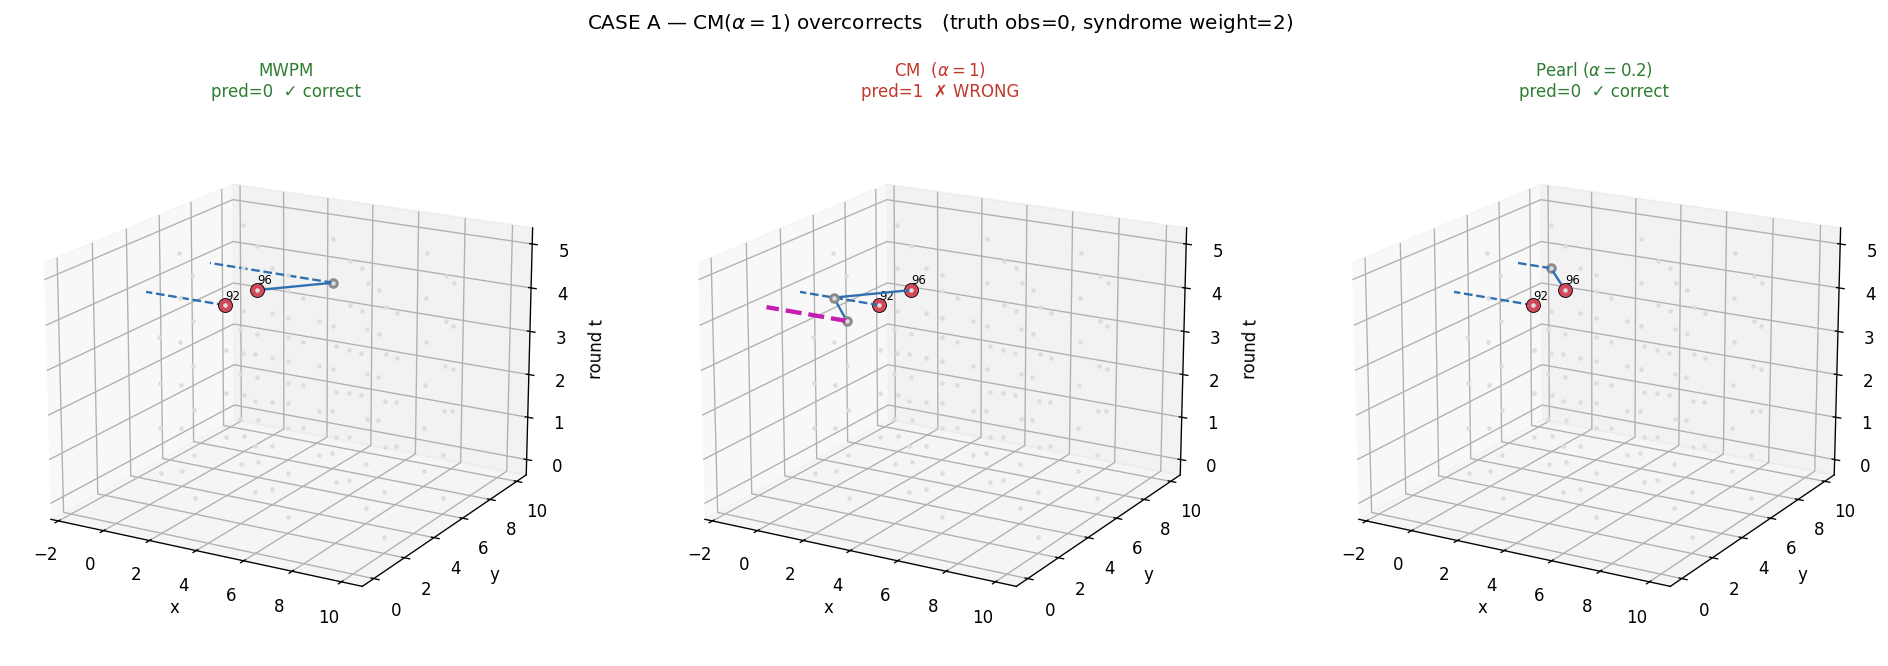

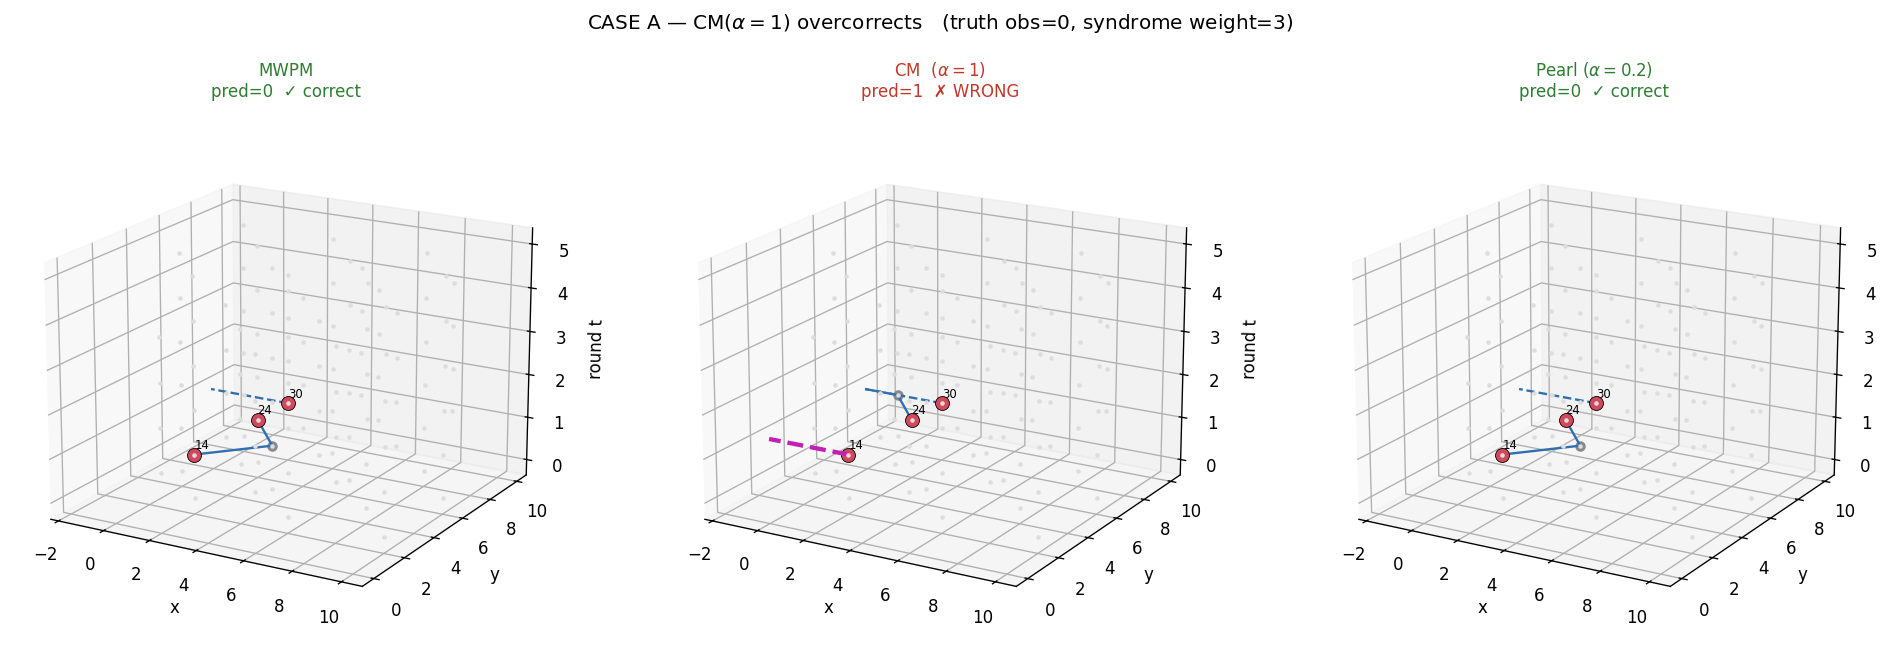

In [7]:
for syn, obs, pr in rowsA[:2]:
    show_shot(syn, obs, "CASE A — CM($\\alpha=1$) overcorrects")

In [8]:
# Anatomy of the first Case-A shot: why does CM take the detour?
syn, obs, pr = rowsA[0]
w = graph.initial_weights
def chain_cost(edges):
    return float(sum(w[P2I[u, v]] for u, v in edges))
for mode, label in MODES:
    edges, parity = decode_edges(syn, mode)
    flip = [(u, v) for u, v in edges if edge_flips_obs(u, v)]
    print(f"{label:16s} pred={parity}  base-weight cost={chain_cost(edges):6.2f}  "
          f"obs-flipping edges={flip}")
print("\nUnder the ORIGINAL weights the CM detour is the more expensive explanation; CM selects it")
print("only because its correlation reweighting discounts those edges below the direct route.")

MWPM             pred=0  base-weight cost= 19.48  obs-flipping edges=[]
CM  ($\alpha=1$) pred=1  base-weight cost= 26.67  obs-flipping edges=[(86, -1)]
Pearl ($\alpha=0.2$) pred=0  base-weight cost= 20.09  obs-flipping edges=[]

Under the ORIGINAL weights the CM detour is the more expensive explanation; CM selects it
only because its correlation reweighting discounts those edges below the direct route.


## 5. Case B — Pearl repairs an MWPM mistake

Here the correlation information is *right*: MWPM, decoding each graph independently, picks the wrong
chain, while a **damped** dose of the same correlation prior ($\alpha{=}0.2$) is enough to steer Pearl
to the correct one. (Full CM is often correct here too — the point is that $\alpha{=}0.2$ already
captures the benefit without the Case-A cost.)

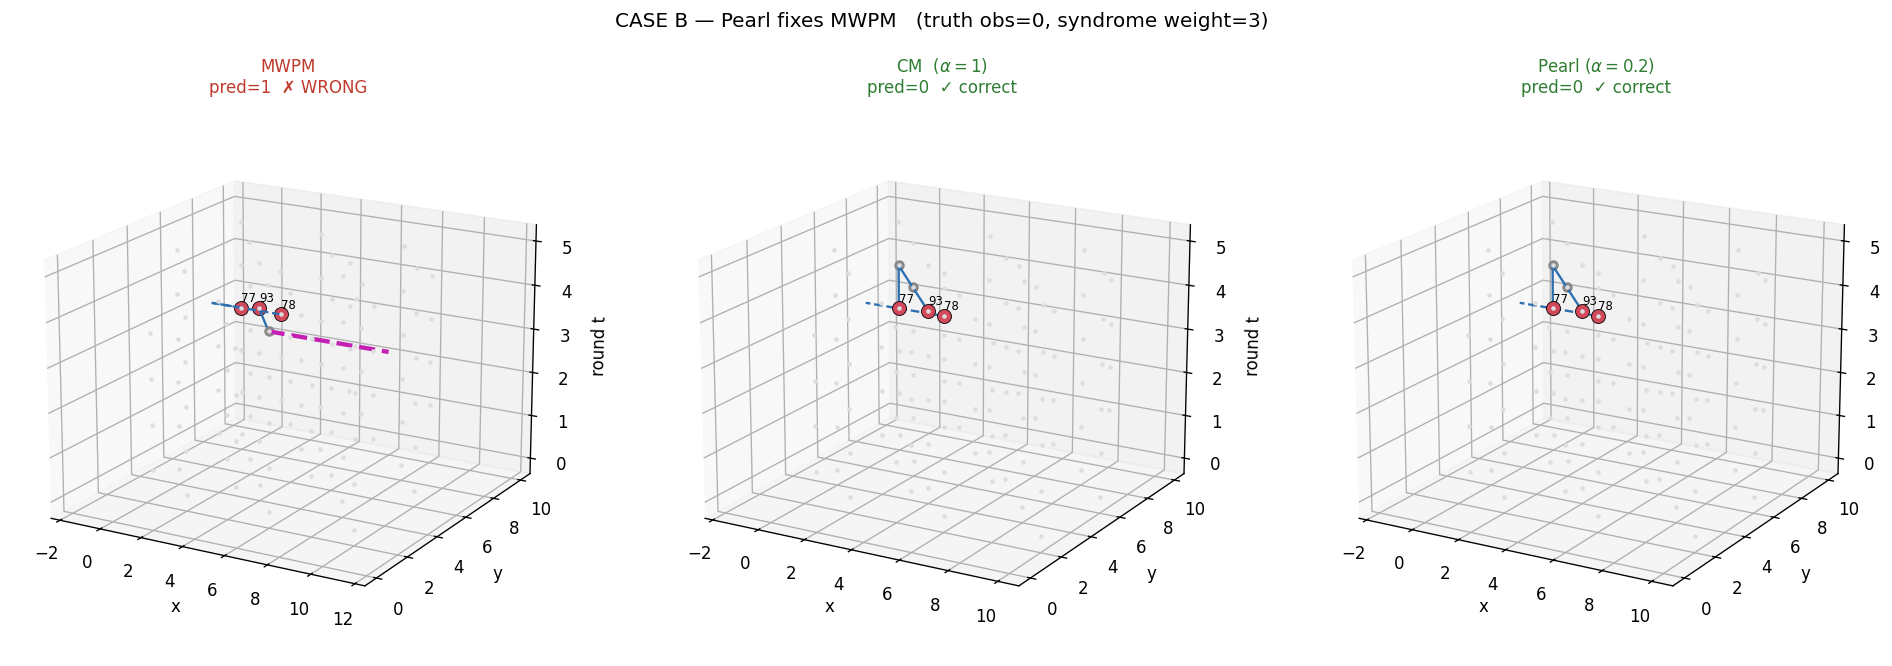

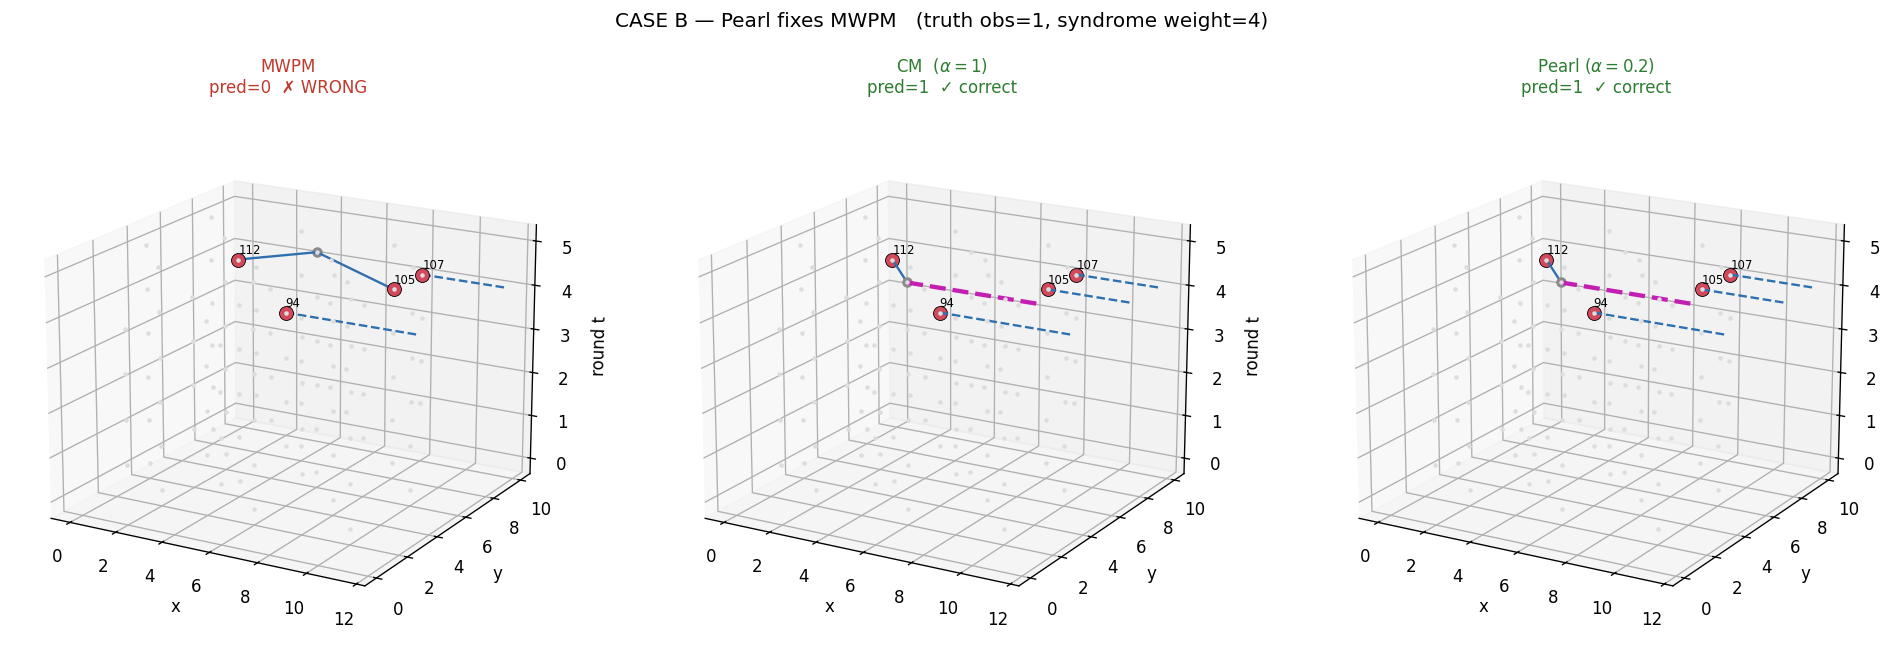

In [9]:
for syn, obs, pr in rowsB[:2]:
    show_shot(syn, obs, "CASE B — Pearl fixes MWPM")

## 6. Fault-distance check: are all weight-1 and weight-2 error chains corrected?

A distance-5 code must correct every error chain of weight $\le\lfloor(5-1)/2\rfloor = 2$. Whether the
*decoder* actually does is a property of the decoder, not just the code — a decoder that fails some
weight-2 chain has **effective distance $\le 4$** and acquires an LER floor $\propto p^2$ (vs the
$p^3$ of a true distance-5 decoder, which needs 3 faults to fail).

Here we enumerate **every DEM fault mechanism** (weight-1 chains) and **every pair of mechanisms**
(weight-2 chains), build each chain's exact syndrome, and decode it with MWPM, CM($\alpha{=}1$) and
Pearl($\alpha{=}0.2$). This is exhaustive — no sampling, no statistics.

In [10]:
# Enumerate DEM mechanisms: (prob, parity-reduced detector set, observable flip).
mechs = []
for inst in dem.flattened():
    if inst.type != "error":
        continue
    pr_ = inst.args_copy()[0]
    dets, ob_ = set(), 0
    for t in inst.targets_copy():
        if t.is_relative_detector_id():
            dets ^= {t.val}
        elif t.is_logical_observable_id():
            ob_ ^= 1
    mechs.append((pr_, tuple(sorted(dets)), ob_))
M = len(mechs)
probs_m = np.array([m[0] for m in mechs])
det_m = np.zeros((M, ND), dtype=np.uint8)
obs_m = np.zeros(M, dtype=np.uint8)
for i, (pr_, dets, ob_) in enumerate(mechs):
    det_m[i, list(dets)] = 1
    obs_m[i] = ob_

def _decode3(shots_):
    return (mwpm.decode_batch(shots_)[:, 0],
            cmat.decode_batch(shots_, enable_correlations=True, alpha=1.0)[:, 0],
            cmat.decode_batch(shots_, enable_correlations=True, alpha=ALPHA_BEST)[:, 0])

# --- weight-1 chains: every decoder must be perfect ---------------------------------
pm_, p1_, pb_ = _decode3(det_m)
print(f"weight-1 chains ({M} mechanisms): failures  "
      f"MWPM={int((pm_!=obs_m).sum())}  CM(1)={int((p1_!=obs_m).sum())}  "
      f"Pearl({ALPHA_BEST})={int((pb_!=obs_m).sum())}")

# --- weight-2 chains: ALL mechanism pairs, decoded in blocks ------------------------
failN = {"MWPM": 0, "CM(1)": 0, f"Pearl({ALPHA_BEST})": 0}
failW = {k: 0.0 for k in failN}
cm_only = []                       # pairs failing for CM(1) while MWPM & Pearl are correct
t0 = time.time()
for i0 in range(0, M, 400):
    blocks, ii, jj = [], [], []
    for i in range(i0, min(i0 + 400, M)):
        j = np.arange(i + 1, M)
        if j.size:
            blocks.append(det_m[i] ^ det_m[i + 1:])
            ii.append(np.full(j.size, i)); jj.append(j)
    if not blocks:
        continue
    shots_ = np.vstack(blocks)
    ii = np.concatenate(ii); jj = np.concatenate(jj)
    ob_ = obs_m[ii] ^ obs_m[jj]
    w_ = probs_m[ii] * probs_m[jj]
    pm_, p1_, pb_ = _decode3(shots_)
    for k, pr_ in (("MWPM", pm_), ("CM(1)", p1_), (f"Pearl({ALPHA_BEST})", pb_)):
        bad = pr_ != ob_
        failN[k] += int(bad.sum()); failW[k] += float(w_[bad].sum())
    for k in np.flatnonzero((p1_ != ob_) & (pm_ == ob_) & (pb_ == ob_)):
        cm_only.append((int(ii[k]), int(jj[k]), float(w_[k])))

npairs = M * (M - 1) // 2
print(f"\nweight-2 chains: all {npairs:,} mechanism pairs decoded exhaustively "
      f"in {time.time()-t0:.0f}s")
print(f"{'decoder':>14} {'failing pairs':>14} {'sum p_i*p_j (2-fault LER)':>27}")
for k in failN:
    print(f"{k:>14} {failN[k]:>14,} {failW[k]:>27.2e}")
print(f"\npairs failing ONLY for CM(1) (MWPM & Pearl both correct): {len(cm_only):,}")

weight-1 chains (1677 mechanisms): failures  MWPM=0  CM(1)=0  Pearl(0.2)=0



weight-2 chains: all 1,405,326 mechanism pairs decoded exhaustively in 16s
       decoder  failing pairs   sum p_i*p_j (2-fault LER)
          MWPM              0                    0.00e+00
         CM(1)            337                    9.77e-07
    Pearl(0.2)              8                    1.42e-08

pairs failing ONLY for CM(1) (MWPM & Pearl both correct): 329


**Reading it.** MWPM corrects *every* weight-1 and weight-2 chain — it preserves the full code
distance 5, which is why its LER scales as $p^3$. CM($\alpha{=}1$) **fails hundreds of weight-2
chains**: full-strength correlated matching has effective distance $\le4$, and the summed probability
of its failing pairs is precisely the $p^2$ LER floor that makes it cross above MWPM at low $p$.
Pearl damping removes almost all of the channel, restoring (nearly) the full distance — this is the
mechanism behind the $\alpha_\text{best}(p)$ laws. Below, the most probable CM-only failing pair,
drawn in the same 3-D panels: the two faults, and what each decoder does with them.

fault 1: mech 223  detectors=(16, 21, 22)  obs_flip=0
fault 2: mech 306  detectors=(21, 22, 25, 26)  obs_flip=0
pair probability p_i*p_j = 1.92e-08    truth obs = 0


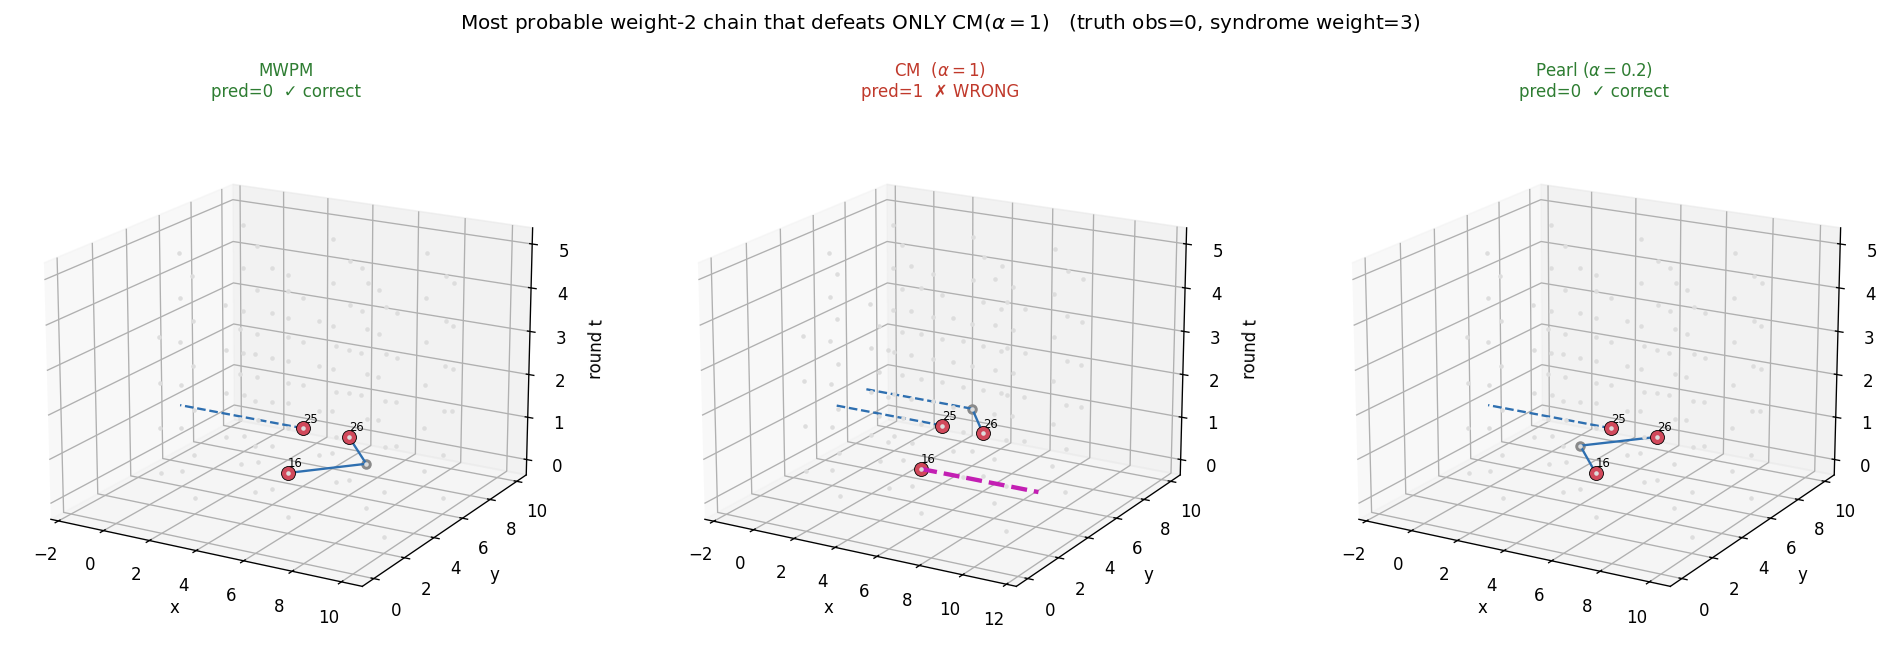

In [11]:
cm_only.sort(key=lambda r: -r[2])
i, j, w_ = cm_only[0]
syn_pair = (det_m[i] ^ det_m[j]).astype(np.uint8)
truth = int(obs_m[i] ^ obs_m[j])
print(f"fault 1: mech {i}  detectors={mechs[i][1]}  obs_flip={mechs[i][2]}")
print(f"fault 2: mech {j}  detectors={mechs[j][1]}  obs_flip={mechs[j][2]}")
print(f"pair probability p_i*p_j = {w_:.2e}    truth obs = {truth}")
show_shot(syn_pair, truth, "Most probable weight-2 chain that defeats ONLY CM($\\alpha=1$)")

## 7. Case C — Pearl succeeds where BOTH CM and MWPM fail

The harvested pools already contain these shots: Case C $=$ Case A $\cap$ Case B (Pearl correct, CM
wrong, *and* MWPM wrong). These are the strongest events for Pearl — it is not merely undoing a CM
overcorrection or adding a correlation MWPM lacks; it finds the right answer where **both** baselines
fail, typically because the shot needs *some* correlation information (MWPM fails) but at full
strength the correction overshoots (CM fails).

Case C (Pearl right, BOTH MWPM and CM wrong): 2 of 20,000,000 shots (rate 1.0e-07)
  Case A (Pearl right, CM wrong)  : 41  -> 2 of them also defeat MWPM
  Case B (Pearl right, MWPM wrong): 79


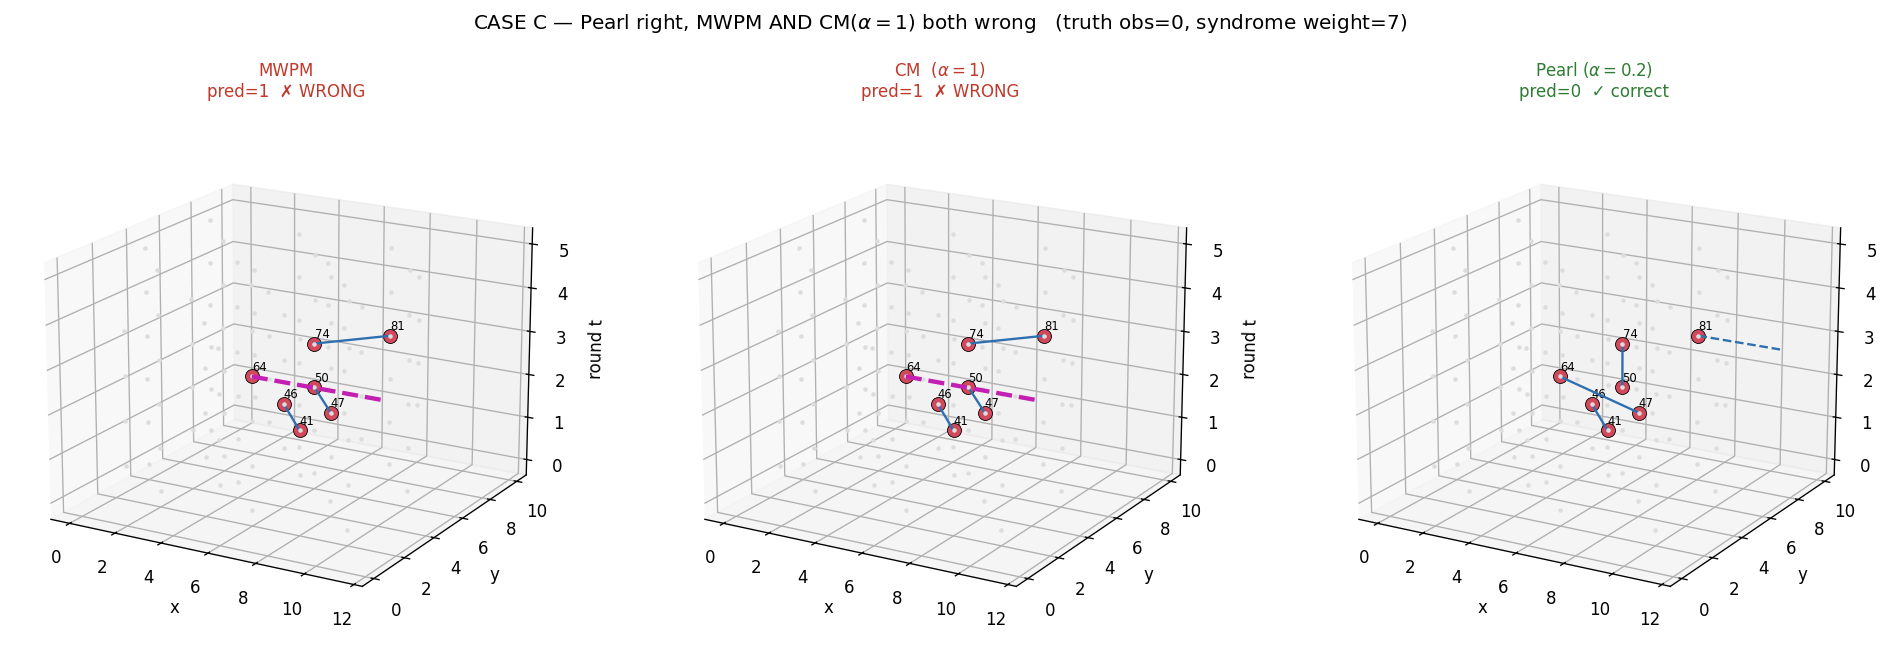

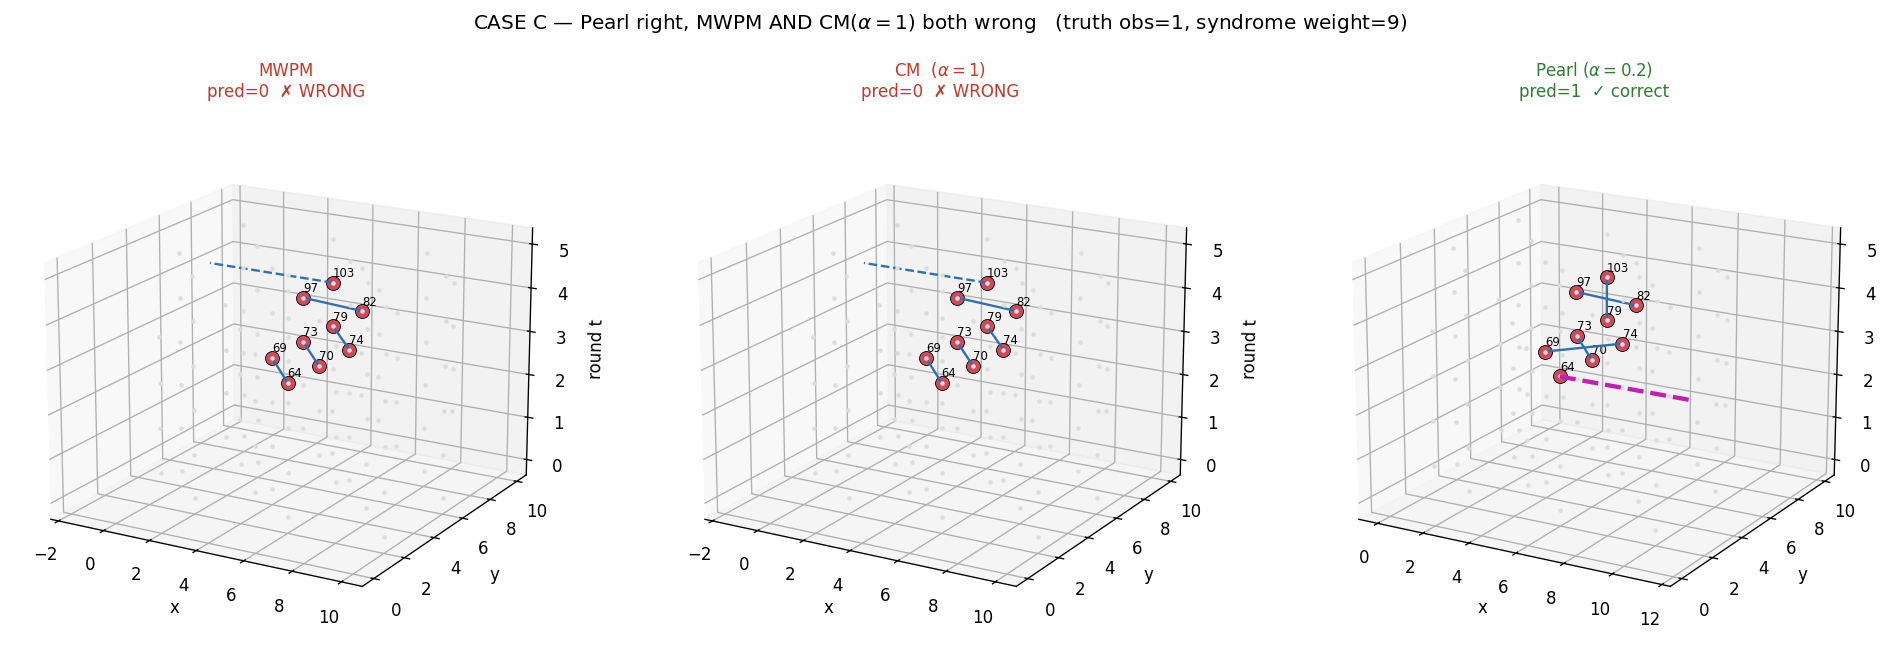

In [12]:
caseC = [(s_, o_, p_) for s_, o_, p_ in caseA if p_["mwpm"] != o_]
print(f"Case C (Pearl right, BOTH MWPM and CM wrong): {len(caseC)} of {TOT:,} shots "
      f"(rate {len(caseC)/TOT:.1e})")
print(f"  Case A (Pearl right, CM wrong)  : {len(caseA)}  -> {len(caseC)} of them also defeat MWPM")
print(f"  Case B (Pearl right, MWPM wrong): {len(caseB)}")
rowsC = sorted(caseC, key=lambda r: int(r[0].sum()))
if rowsC:
    for s_, o_, p_ in rowsC[:2]:
        show_shot(s_, o_, "CASE C — Pearl right, MWPM AND CM($\\alpha=1$) both wrong")
else:
    print("none in the cached budget — raise MAX_CHUNKS / WANT_A / WANT_B and re-harvest")

## 8. Mechanism, and the link to the $\alpha_\text{best}(p)$ laws

**What a Case-A shot shows.** A lone fired detector must be matched to the boundary. Two explanations
compete: the **direct** boundary route (honest weights) and a **detour** through edges that share a
correlated fault mechanism with an already-matched edge. Correlated matching reduces the detour edges'
weights to $w^{\rm imp}=-\log\!\big(\alpha\,P(\mu\mid\nu)\big)$. At $\alpha=1$ that pins them near
$\mathcal{O}(1)$ — *nearly free*. Since $p=4\times10^{-4}$ makes the honest edges cost
$\sim|\log p|\approx 6$–$8$ (we printed exactly these: direct $\approx14$ vs detour $\approx22$ under
base weights), the near-free detour wins the min-weight matching **even though it is the less likely
explanation**, and it happens to cross the logical operator $\Rightarrow$ a logical error CM inflicts
on a shot that needed no correction. Pearl at $\alpha=0.2$ lifts the detour edges back to
$-\log(0.2\cdot P)$, the honest route re-wins, and the shot is decoded correctly.

**What a Case-B shot shows.** The mirror image: sometimes the correlated detour *is* the true
explanation, and MWPM's independent per-graph matching misses it. A damped correlation ($\alpha=0.2$)
is already enough to make that true edge cheap enough to be selected — the benefit is captured without
the full-strength over-commitment.

**Why this is exactly the $\alpha_\text{best}$ story.** The companion notebook
(`alpha_best_functional_relation.ipynb`) found $\alpha_\text{best}$ rising with $p$, best described by
a **saturating law** $L/(1+(p_0/p)^m)$ with plateau $L\approx0.75$ and a power-law low-$p$ tail — the
signature of a **broken scale invariance**: all honest edge weights scale like $|\log p|$, but the
correlation conditional pins the boosted edge at $-\log(\alpha P)=|\log\alpha|+\mathcal{O}(1)$, which
does *not*. As $p\to0$ the boosted edge becomes ever freer relative to the ambient scale, so full CM
detours ever more readily — Case A gets more frequent — and $\alpha$ must shrink like a power of $p$ to
keep the boosted edge a controlled fraction of $|\log p|$. At $p=4\times10^{-4}$ that trade-off lands
at $\alpha_\text{best}\approx0.2$: small enough that the Case-A detours we just saw are suppressed,
large enough that the Case-B repairs still fire. The per-shot pictures are the microscopic events
behind the macroscopic $\alpha_\text{best}(p)$ curve: Case-A overcorrections grow *relative to* Case-B
repairs as $p$ falls (the pinned boosted edges get ever freer), which is what drives
$\alpha_\text{best}$ down its power-law tail toward $0$ — while at higher $p$ the repairs dominate and
$\alpha_\text{best}$ climbs to its plateau.

In [13]:
# Where alpha_best comes from, per-shot, at this (d,p).
print(f"At d={D}, p={P:g}  (alpha_best = {ALPHA_BEST}):\n")
print(f"  Correlations NET HELP here: CM(1.0) beats MWPM "
      f"({T['err_cm']} vs {T['err_mwpm']} logical errors),")
print(f"  because help events outnumber overcorrections "
      f"(CM right/MWPM wrong = {T['cm_helps']}  >  CM wrong/MWPM right = {T['cm_overcorrect']}).")
print(f"  That is why alpha_best > 0 at all.\n")
print(f"  But alpha=1 is NOT optimal: damping 1.0 -> {ALPHA_BEST} strictly improves LER by")
print(f"  recovering the Case-A overcorrections while keeping the Case-B repairs:")
print(f"    Case A rate (full CM overcorrects, Pearl saves): {len(caseA)/TOT:.2e}")
print(f"    Case B rate (MWPM wrong, Pearl repairs):         {len(caseB)/TOT:.2e}")
print(f"\n  The balance of these two per-shot events pins alpha_best at ~{ALPHA_BEST}. As p decreases")
print(f"  further, the pinned near-free boosted edges (Section 6) make Case-A grow relative to Case-B,")
print(f"  so alpha_best is pulled down toward 0 -- the low-p tail of the alpha_best(p) law.")

At d=5, p=0.0004  (alpha_best = 0.2):

  Correlations NET HELP here: CM(1.0) beats MWPM (114 vs 154 logical errors),
  because help events outnumber overcorrections (CM right/MWPM wrong = 91  >  CM wrong/MWPM right = 51).
  That is why alpha_best > 0 at all.

  But alpha=1 is NOT optimal: damping 1.0 -> 0.2 strictly improves LER by
  recovering the Case-A overcorrections while keeping the Case-B repairs:
    Case A rate (full CM overcorrects, Pearl saves): 2.05e-06
    Case B rate (MWPM wrong, Pearl repairs):         3.95e-06

  The balance of these two per-shot events pins alpha_best at ~0.2. As p decreases
  further, the pinned near-free boosted edges (Section 6) make Case-A grow relative to Case-B,
  so alpha_best is pulled down toward 0 -- the low-p tail of the alpha_best(p) law.
